# Recover catalogued streams with a mock-trained blob CPEN

Score `best.ckpt` from the **mock-blob** training run on the mock-less `train/0000` graphs
(`galaxies_real`). Labels here are catalogued S5 members (`is_mock_stream` was aliased at
build time). The network never saw these stars in training.

**Honest operating point:** pick $t^\star$ on a mock **val** subsample, then apply that cut
to real 0000. An oracle sweep on S5 is shown for comparison — that is a diagnostic, not
the discovery threshold.

If the current Slurm job is still running, this notebook uses `last.ckpt` until `best.ckpt`
stops updating. Re-run the load cell after the job finishes.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from sklearn.metrics import average_precision_score, roc_auc_score

REPO = Path("../..").resolve()
sys.path[:0] = [str(REPO), str(REPO / "src")]

from cpen.apps.streams.blob_graph_cache import (
    DEFAULT_BLOB_DATA_DIR,
    blob_to_incidence_payload,
    fit_feature_stats,
    load_split_manifest,
    n_edge_features,
    n_node_features,
    select_eval_graphs,
    select_train_graphs,
)
from cpen.apps.streams.preprocess.config import DEFAULT_REAL_PIPELINE_ROOT
from cpen.apps.streams.preprocess.utils import blob_stem
from cpen.lit_models.lit_cpen_stream import LitCPENStream
from cpen.models.cpen import CPEN

try:
    import scienceplots  # noqa: F401
    plt.style.use(["science", "no-latex"])
except Exception:
    pass
mpl.rcParams.update({"figure.dpi": 140, "savefig.dpi": 300})

MOCK_ROOT = Path(DEFAULT_BLOB_DATA_DIR)
REAL_OUT = Path(DEFAULT_REAL_PIPELINE_ROOT) / "train" / "0000"
RUNS_ROOT = Path("/scratch/gpfs/BHANIN/jdezoort/cpen_runs/blobs")
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
DROP_FEATURES = "parallax"
NODE_FRAME = "local"
MIN_STARS = 16
# Score every S5-host blob plus this many empty field blobs (set None for all).
N_EMPTY_SAMPLE = 400
N_MOCK_VAL_FOR_THRESH = 400
print(f"device {DEVICE}")
print(f"mock graphs {MOCK_ROOT}")
print(f"real 0000  {REAL_OUT}")


device cuda
mock graphs /scratch/gpfs/BHANIN/jgdezoort/streams/galaxies
real 0000  /scratch/gpfs/BHANIN/jgdezoort/streams/galaxies_real/train/0000


## Locate the current blob run and checkpoint


In [2]:
def latest_blob_run(runs_root: Path) -> Path:
    """Newest directory under runs_root that contains last.ckpt or best.ckpt."""
    ckpts = list(runs_root.glob("**/last.ckpt")) + list(runs_root.glob("**/best.ckpt"))
    if not ckpts:
        raise FileNotFoundError(f"No blob checkpoints under {runs_root}")
    run = max((p.parent for p in ckpts), key=lambda d: (d / "last.ckpt").stat().st_mtime
              if (d / "last.ckpt").is_file() else (d / "best.ckpt").stat().st_mtime)
    return run


def pick_ckpt(run_dir: Path) -> Path:
    best, last = run_dir / "best.ckpt", run_dir / "last.ckpt"
    if last.is_file() and best.is_file():
        # Prefer best; warn if last is newer (job still running).
        if last.stat().st_mtime > best.stat().st_mtime + 5:
            print("last.ckpt is newer than best.ckpt — training still running; using last.ckpt")
            return last
        return best
    if best.is_file():
        return best
    if last.is_file():
        print("best.ckpt missing; using last.ckpt")
        return last
    raise FileNotFoundError(run_dir)


RUN_DIR = latest_blob_run(RUNS_ROOT)
PARQUET = Path(str(RUN_DIR) + ".parquet")
if not PARQUET.is_file():
    matches = list(RUN_DIR.parent.glob(RUN_DIR.name + ".parquet"))
    PARQUET = matches[0] if matches else PARQUET
CKPT = pick_ckpt(RUN_DIR)
print(f"run  {RUN_DIR}")
print(f"ckpt {CKPT}  ({CKPT.stat().st_size/1e6:.1f} MB)")
print(f"log  {PARQUET}  exists={PARQUET.is_file()}")

if PARQUET.is_file():
    hist = pd.read_parquet(PARQUET)
    ep = hist.loc[hist["record_type"] == "epoch"].sort_values("epoch") if "record_type" in hist.columns else hist
    n_ep = int(ep["epoch"].max()) + 1 if len(ep) else 0
    n_max = int(hist["epochs"].iloc[-1]) if "epochs" in hist.columns else None
    va = ep["val_auroc"].dropna() if "val_auroc" in ep.columns else pd.Series(dtype=float)
    print(f"logged epochs {n_ep}/{n_max}  last val_auroc={float(va.iloc[-1]) if len(va) else float('nan'):.4f}")
    if n_max is not None and n_ep < n_max:
        print("Training is not finished. Re-run this cell (and reload the module) when the job ends.")
else:
    hist = None
    ep = pd.DataFrame()
    print("No parquet log — hparams will use checkpoint / defaults.")


last.ckpt is newer than best.ckpt — training still running; using last.ckpt
run  /scratch/gpfs/BHANIN/jdezoort/cpen_runs/blobs/stream_output/adamw/sweep_lr/cpen_4_256_0p2_t5_ln_cosine_op-incidence_onorm-degree_res-transformer-like_drop0p2_nf6_gnativeedges_blobs-dropparallax-hyper-edgecons
ckpt /scratch/gpfs/BHANIN/jdezoort/cpen_runs/blobs/stream_output/adamw/sweep_lr/cpen_4_256_0p2_t5_ln_cosine_op-incidence_onorm-degree_res-transformer-like_drop0p2_nf6_gnativeedges_blobs-dropparallax-hyper-edgecons/last.ckpt  (66.2 MB)
log  /scratch/gpfs/BHANIN/jdezoort/cpen_runs/blobs/stream_output/adamw/sweep_lr/cpen_4_256_0p2_t5_ln_cosine_op-incidence_onorm-degree_res-transformer-like_drop0p2_nf6_gnativeedges_blobs-dropparallax-hyper-edgecons.parquet  exists=True
logged epochs 17/20  last val_auroc=0.9751
Training is not finished. Re-run this cell (and reload the module) when the job ends.


## Training curves (mock val)


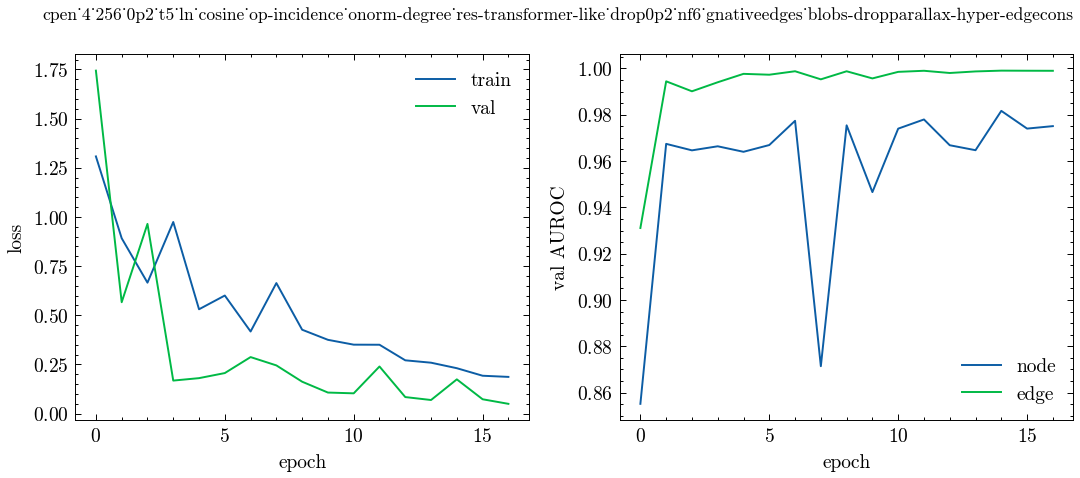

In [3]:
if hist is not None and len(ep):
    fig, axs = plt.subplots(1, 2, figsize=(9.2, 3.4))
    axs[0].plot(ep["epoch"], ep["train_loss"], label="train")
    if "val_loss" in ep.columns:
        axs[0].plot(ep["epoch"], ep["val_loss"], label="val")
    axs[0].set_xlabel("epoch"); axs[0].set_ylabel("loss"); axs[0].legend()
    if "val_auroc" in ep.columns:
        axs[1].plot(ep["epoch"], ep["val_auroc"], label="node")
    if "val_edge_auroc" in ep.columns:
        axs[1].plot(ep["epoch"], ep["val_edge_auroc"], label="edge")
    axs[1].set_xlabel("epoch"); axs[1].set_ylabel("val AUROC"); axs[1].legend()
    fig.suptitle(RUN_DIR.name, fontsize=9)
    plt.show()
else:
    print("No epoch rows to plot.")


## Load `best.ckpt` / `last.ckpt`

Feature standardization is refit from the **mock train** pool (same recipe as training),
not from the real sky. Node features: local $d\phi,d\lambda,g,r,\mu_{\alpha*},\mu_\delta$ (parallax withheld).


In [4]:
def run_hparams(hist: pd.DataFrame | None) -> dict:
    defaults = dict(
        depth=4, width=256, eta_0=0.2, dropout=0.2,
        residual_structure="transformer-like",
        operator_normalization="degree", layer_norm=True,
        n_features=6, n_edge_features=4,
    )
    if hist is None or hist.empty:
        return defaults
    row = hist.iloc[-1]
    def _get(key, default):
        if key not in row.index or pd.isna(row[key]):
            return default
        return row[key]
    return dict(
        depth=int(_get("depth", defaults["depth"])),
        width=int(_get("width", defaults["width"])),
        eta_0=float(_get("eta_0", defaults["eta_0"])),
        dropout=float(_get("dropout", defaults["dropout"]) or 0.0),
        residual_structure=str(_get("residual_structure", defaults["residual_structure"])),
        operator_normalization=str(_get("operator_normalization", defaults["operator_normalization"])),
        layer_norm=bool(_get("layer_norm", defaults["layer_norm"])),
        n_features=int(_get("n_features", defaults["n_features"])),
        n_edge_features=int(_get("n_edge_features", defaults["n_edge_features"])),
    )


hp = run_hparams(hist)
nf = n_node_features(NODE_FRAME, DROP_FEATURES)
ne = n_edge_features(DROP_FEATURES)
assert nf == hp["n_features"], (nf, hp["n_features"])
print(hp)

print("Fitting mock-train feature stats (same split recipe as training)…")
train_man = select_train_graphs(
    load_split_manifest(MOCK_ROOT, "train"),
    rich_min_mock=100, empty_per_rich=1.0, min_stars=MIN_STARS, seed=0,
)
STATS = fit_feature_stats(
    list(train_man["path"]),
    node_frame=NODE_FRAME,
    drop_features=DROP_FEATURES,
    include_hyperedges=True,
    seed=0,
)
print(f"stats from {len(train_man):,} mock train graphs")

model = CPEN(
    n_features=nf,
    n_edge_features=ne,
    out_dim=2,
    depth=hp["depth"],
    width=hp["width"],
    operators="incidence",
    normalization="uniform",
    residual_structure=hp["residual_structure"],
    operator_normalization=hp["operator_normalization"],
    operator_backend="sparse",
    layer_norm=hp["layer_norm"],
    dropout=hp["dropout"],
    readout_mode="node+edge",
)
lit = LitCPENStream.load_from_checkpoint(
    str(CKPT),
    model=model,
    eta_0=hp["eta_0"],
    model_name="cpen",
    optimizer="adamw",
    dataset="stream",
    depth=hp["depth"],
    width=hp["width"],
    map_location="cpu",
    strict=False,
)
lit.eval()
lit.to(DEVICE)
print(f"loaded {CKPT.name} on {DEVICE}")


{'depth': 4, 'width': 256, 'eta_0': 0.2, 'dropout': 0.2, 'residual_structure': 'transformer-like', 'operator_normalization': 'degree', 'layer_norm': True, 'n_features': 6, 'n_edge_features': 4}
Fitting mock-train feature stats (same split recipe as training)…
stats from 956 mock train graphs


/home/jdezoort/.conda/envs/mamba-env/lib/python3.10/site-packages/lightning/fabric/utilities/cloud_io.py:56: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.


loaded last.ckpt on cuda


## Score real 0000 blobs

Every star is in the discovery pool (`role='test'` → `train_mask` all False).
`y` is S5 membership. Per-star `stream_label` is read from the matching blob parquet
when it exists.


In [5]:
def _auroc(score, target):
    y = np.asarray(target).astype(int)
    s = np.asarray(score)
    if y.size == 0 or len(np.unique(y)) < 2:
        return float("nan")
    return float(roc_auc_score(y, s))


def _ap(score, target):
    y = np.asarray(target).astype(int)
    s = np.asarray(score)
    if y.size == 0 or y.sum() == 0:
        return float("nan")
    return float(average_precision_score(y, s))


def sky_from_npz(path: Path):
    with np.load(path) as z:
        raw = z["x"].astype(np.float32)
        y = z["y"].astype(bool)
        cid = int(z["cell_id"])
        gmm = int(z["gmm_label"])
        part = int(z["blob_part"])
    ra = np.degrees(np.arctan2(raw[:, 0], raw[:, 1]))
    dec = raw[:, 2]
    return ra, dec, y, cid, gmm, part


def load_stream_labels(cid: int, gmm: int, part: int, n: int) -> np.ndarray:
    fp = REAL_OUT / "blobs" / f"{blob_stem((cid, gmm, part))}.parquet"
    if not fp.is_file():
        return np.array(["?"] * n, dtype=object)
    df = pd.read_parquet(fp, columns=["stream_label"])
    if "stream_label" not in df.columns or len(df) != n:
        return np.array(["?"] * n, dtype=object)
    return df["stream_label"].astype(str).to_numpy()


@torch.no_grad()
def score_npz(path: Path) -> dict:
    payload = blob_to_incidence_payload(
        path, role="test", node_frame=NODE_FRAME,
        drop_features=DROP_FEATURES, stats=STATS, include_hyperedges=True,
    )
    batch = {
        k: payload[k].unsqueeze(0).to(DEVICE)
        for k in (
            "x", "edge_x", "incidence_node", "incidence_edge",
            "incidence_nnz", "node_degree_inv", "edge_degree_inv", "mask",
        )
    }
    node_logits, edge_logits = lit.model(batch["x"], **lit._model_kwargs(batch))
    p_node = F.softmax(node_logits[0], dim=-1)[:, 1].detach().cpu().numpy()
    p_edge = F.softmax(edge_logits[0], dim=-1)[:, 1].detach().cpu().numpy()
    ra, dec, y, cid, gmm, part = sky_from_npz(path)
    labels = load_stream_labels(cid, gmm, part, len(y))
    return dict(
        path=str(path), cell_id=cid, gmm_label=gmm, blob_part=part,
        ra=ra, dec=dec, y=y, labels=labels,
        p_node=p_node, p_edge=p_edge,
        n_stars=int(len(y)), n_s5=int(y.sum()),
        mean_p=float(p_node.mean()),
        mean_p_s5=float(p_node[y].mean()) if y.any() else float("nan"),
        auroc=_auroc(p_node, y),
        ap=_ap(p_node, y),
    )


man = pd.read_parquet(REAL_OUT / "graphs" / "manifest.parquet")
man = man.loc[man.n_stars >= MIN_STARS].copy()
man["path"] = [str(REAL_OUT / "graphs" / f) for f in man["file"]]
hosts = man.loc[man.n_mock > 0]
empty = man.loc[man.n_mock == 0]
if N_EMPTY_SAMPLE is None:
    take = man
else:
    rng = np.random.default_rng(0)
    n_take = min(int(N_EMPTY_SAMPLE), len(empty))
    empty_s = empty.iloc[rng.choice(len(empty), n_take, replace=False)] if n_take else empty.iloc[0:0]
    take = pd.concat([hosts, empty_s], ignore_index=True)
print(f"scoring {len(take):,} blobs  (hosts {len(hosts):,} + empty sample {len(take)-len(hosts):,})")
print(f"S5 stars in hosts {int(hosts.n_mock.sum()):,} / {int(man.n_mock.sum()):,} in full manifest")

scored = []
for i, row in enumerate(take.itertuples(index=False), start=1):
    scored.append(score_npz(Path(row.path)))
    if i % 50 == 0 or i == len(take):
        print(f"  [{i}/{len(take)}]", flush=True)

p_all = np.concatenate([r["p_node"] for r in scored])
y_all = np.concatenate([r["y"] for r in scored])
print(f"pooled node AUROC={_auroc(p_all, y_all):.4f}  AP={_ap(p_all, y_all):.4f}  "
      f"S5 frac={y_all.mean():.4f}  N={len(y_all):,}")
blob_tab = pd.DataFrame([
    {k: r[k] for k in ("cell_id", "gmm_label", "blob_part", "n_stars", "n_s5",
                       "mean_p", "mean_p_s5", "auroc", "ap")}
    for r in scored
])
display(blob_tab.sort_values("n_s5", ascending=False).head(12))


scoring 1,569 blobs  (hosts 1,169 + empty sample 400)
S5 stars in hosts 37,813 / 37,813 in full manifest
  [50/1569]
  [100/1569]
  [150/1569]
  [200/1569]
  [250/1569]
  [300/1569]
  [350/1569]
  [400/1569]
  [450/1569]
  [500/1569]
  [550/1569]
  [600/1569]
  [650/1569]
  [700/1569]
  [750/1569]
  [800/1569]
  [850/1569]
  [900/1569]
  [950/1569]
  [1000/1569]
  [1050/1569]
  [1100/1569]
  [1150/1569]
  [1200/1569]
  [1250/1569]
  [1300/1569]
  [1350/1569]
  [1400/1569]
  [1450/1569]
  [1500/1569]
  [1550/1569]
  [1569/1569]
pooled node AUROC=0.5300  AP=0.0235  S5 frac=0.0220  N=1,719,954


,cell_id,gmm_label,blob_part,n_stars,n_s5,mean_p,mean_p_s5,auroc,ap
1129,109,37,0,2566,932,0.001602,0.002548,0.546755,0.394032
310,19,6,0,6687,896,0.018073,0.013685,0.513179,0.133735
377,23,1,0,4332,885,0.019674,0.015300,0.484549,0.191552
998,103,14,0,3655,673,0.017550,0.011040,0.478746,0.170733
351,21,11,0,5525,648,0.012934,0.009689,0.435581,0.100310
1105,108,55,0,2263,603,0.001070,0.001323,0.531596,0.289235
275,16,58,0,3719,548,0.008394,0.004578,0.481967,0.137883
520,28,38,0,5489,493,0.008048,0.004018,0.444284,0.076796
67,4,23,0,4033,443,0.028738,0.013047,0.406354,0.087022
393,24,26,0,3219,399,0.017756,0.013612,0.463562,0.115455


## Per-stream ranking (S5 names)

Pooled over scored blobs. Empty / Background rows are the field.


In [6]:
lab_all = np.concatenate([r["labels"] for r in scored])
per = []
names = sorted(
    {str(x) for x in lab_all if str(x) not in {"Background", "?"}}
)
for name in names:
    p_mem, p_fld = [], []
    for r in scored:
        m = r["labels"] == name
        if not m.any():
            continue
        p_mem.append(r["p_node"][m])
        p_fld.append(r["p_node"][~m])
    if not p_mem:
        continue
    pm = np.concatenate(p_mem)
    pf = np.concatenate(p_fld) if p_fld else np.zeros(0)
    y = np.concatenate([np.ones(len(pm)), np.zeros(len(pf))]) if len(pf) else np.ones(len(pm))
    s = np.concatenate([pm, pf]) if len(pf) else pm
    per.append(dict(
        stream_label=name,
        n_members=int(len(pm)),
        mean_p_members=float(pm.mean()),
        mean_p_field=float(pf.mean()) if len(pf) else float("nan"),
        auroc=_auroc(s, y) if len(pf) and len(np.unique(y)) == 2 else float("nan"),
        ap=_ap(s, y) if len(pm) else float("nan"),
    ))
per_tab = pd.DataFrame(per).sort_values("n_members", ascending=False)
display(per_tab)


,stream_label,n_members,mean_p_members,mean_p_field,auroc,ap
9,Jhelum,7628,0.001382,0.004726,0.460560,0.020752
3,AAU,3909,0.004059,0.004008,0.510189,0.030042
8,Indus,2563,0.004508,0.007621,0.480345,0.013080
4,Chenab,2358,0.006643,0.007036,0.558719,0.017537
16,Ravi,2248,0.003898,0.006038,0.516883,0.012615
22,Wambelong,2243,0.010116,0.009854,0.539893,0.015606
12,Ngc1904,1959,0.006264,0.013573,0.500394,0.014329
6,Epod,1822,0.004046,0.005115,0.491386,0.019969
18,T3e,1767,0.008670,0.005796,0.537061,0.012706
11,Ngc1851,1709,0.010453,0.012528,0.576218,0.025885


## Threshold: mock-val $t^\star$ vs oracle S5 sweep

Mock-val F1 cut is the one you would actually apply. The S5 sweep is only to see
what recovery is available if you were allowed to tune on the catalog.


Scoring 400 mock val graphs for t* …
  mock val [50/400]
  mock val [100/400]
  mock val [150/400]
  mock val [200/400]
  mock val [250/400]
  mock val [300/400]
  mock val [350/400]
  mock val [400/400]
mock-val t* (max F1) = 0.95


,t,tp,fp,fn,tn,precision,recall,f1
18,0.95,2539,112,258,354181,0.957752,0.907758,0.932085


S5 oracle (max F1 on real labels) — diagnostic only:


,t,tp,fp,fn,tn,precision,recall,f1
0,0.05,1085,49121,36728,1633020,0.021611,0.028694,0.024654


Real sky at mock-val t*:


,tp,fp,fn,tn,precision,recall,f1
0,9,688,37804,1681453,0.012912,0.000238,0.000467


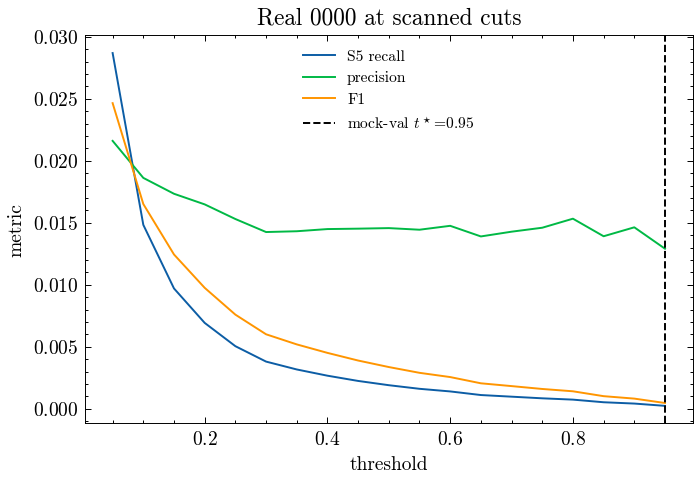

In [7]:
def confusion(score, target, t):
    y = np.asarray(target).astype(bool)
    pred = np.asarray(score) >= t
    tp = int((pred & y).sum()); fp = int((pred & ~y).sum())
    fn = int((~pred & y).sum()); tn = int((~pred & ~y).sum())
    prec = tp / (tp + fp) if (tp + fp) else float("nan")
    rec = tp / (tp + fn) if (tp + fn) else float("nan")
    f1 = 2 * prec * rec / (prec + rec) if (prec + rec) and np.isfinite(prec + rec) else float("nan")
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, precision=prec, recall=rec, f1=f1)


def sweep(score, target, ts=np.linspace(0.05, 0.95, 19)):
    rows = [dict(t=float(t), **confusion(score, target, float(t))) for t in ts]
    return pd.DataFrame(rows)


print(f"Scoring {N_MOCK_VAL_FOR_THRESH} mock val graphs for t* …")
val_man = select_eval_graphs(
    load_split_manifest(MOCK_ROOT, "val"),
    max_graphs=N_MOCK_VAL_FOR_THRESH, min_stars=MIN_STARS, seed=0,
)
p_val, y_val = [], []
for i, path in enumerate(val_man["path"], start=1):
    payload = blob_to_incidence_payload(
        path, role="test", node_frame=NODE_FRAME,
        drop_features=DROP_FEATURES, stats=STATS, include_hyperedges=True,
    )
    batch = {
        k: payload[k].unsqueeze(0).to(DEVICE)
        for k in (
            "x", "edge_x", "incidence_node", "incidence_edge",
            "incidence_nnz", "node_degree_inv", "edge_degree_inv", "mask",
        )
    }
    with torch.no_grad():
        node_logits, _ = lit.model(batch["x"], **lit._model_kwargs(batch))
        p_val.append(F.softmax(node_logits[0], dim=-1)[:, 1].detach().cpu().numpy())
    y_val.append(payload["y"].cpu().numpy().astype(bool))
    if i % 50 == 0 or i == len(val_man):
        print(f"  mock val [{i}/{len(val_man)}]", flush=True)
p_val = np.concatenate(p_val); y_val = np.concatenate(y_val)
val_sweep = sweep(p_val, y_val)
i_star = int(val_sweep["f1"].idxmax())
T_STAR = float(val_sweep.loc[i_star, "t"])
print(f"mock-val t* (max F1) = {T_STAR:.2f}")
display(val_sweep.loc[[i_star]])

real_sweep = sweep(p_all, y_all)
i_or = int(real_sweep["f1"].idxmax())
print("S5 oracle (max F1 on real labels) — diagnostic only:")
display(real_sweep.loc[[i_or]])
print("Real sky at mock-val t*:")
display(pd.DataFrame([confusion(p_all, y_all, T_STAR)]))

fig, ax = plt.subplots(figsize=(5.6, 3.6))
ax.plot(real_sweep.t, real_sweep.recall, label="S5 recall")
ax.plot(real_sweep.t, real_sweep.precision, label="precision")
ax.plot(real_sweep.t, real_sweep.f1, label="F1")
ax.axvline(T_STAR, color="k", ls="--", lw=1, label=rf"mock-val $t^\star$={T_STAR:.2f}")
ax.set_xlabel("threshold"); ax.set_ylabel("metric"); ax.legend(fontsize=8)
ax.set_title("Real 0000 at scanned cuts")
plt.show()


## Completeness of each named stream at mock-val $t^\star$


In [ ]:
comp = []
pred = p_all >= T_STAR
for name, n in pd.Series(lab_all[y_all]).value_counts().items():
    m = (lab_all == name) & y_all
    rec = float(pred[m].mean()) if m.any() else float("nan")
    comp.append(dict(stream_label=name, n_s5=int(m.sum()), recall_at_tstar=rec,
                     mean_p=float(p_all[m].mean())))
comp_tab = pd.DataFrame(comp).sort_values("n_s5", ascending=False)
display(comp_tab)

fig, ax = plt.subplots(figsize=(7.2, 3.6))
ax.bar(np.arange(len(comp_tab)), comp_tab.recall_at_tstar, color="#c0392b", alpha=0.85)
ax.set_xticks(np.arange(len(comp_tab)))
ax.set_xticklabels(comp_tab.stream_label, rotation=30, ha="right")
ax.set_ylabel(rf"recall at $t^\star$={T_STAR:.2f}")
ax.set_ylim(0, 1.05)
ax.set_title("Catalogued-stream recovery (mock-trained CPEN, mock-val cut)")
ax.grid(True, axis="y", ls=":", alpha=0.4)
plt.show()


## Sky maps of the S5-richest blobs

Left: catalog membership. Right: $p(\mathrm{stream})$ and the mock-val cut.


In [ ]:
def plot_blob(r, t=T_STAR, max_bg=8_000, seed=0):
    rng = np.random.default_rng(seed)
    y, p, ra, dec = r["y"], r["p_node"], r["ra"], r["dec"]
    bg = np.flatnonzero(~y)
    if len(bg) > max_bg:
        bg = rng.choice(bg, max_bg, replace=False)
    fig, axs = plt.subplots(1, 2, figsize=(9.6, 4.2), sharex=True, sharey=True)
    axs[0].scatter(ra[bg], dec[bg], s=2, c="#b0b0b0", alpha=0.35, linewidths=0)
    for name in pd.Index(r["labels"][y]).value_counts().index:
        m = (r["labels"] == name) & y
        axs[0].scatter(ra[m], dec[m], s=10, alpha=0.9, label=f"{name} ({int(m.sum())})")
    axs[0].legend(fontsize=7, loc="best")
    axs[0].set_title("catalog S5")
    sc = axs[1].scatter(ra, dec, s=4, c=p, cmap="magma", vmin=0, vmax=1, linewidths=0)
    hit = p >= t
    axs[1].scatter(ra[hit & y], dec[hit & y], s=14, facecolors="none", edgecolors="lime",
                   linewidths=0.6, label="TP")
    axs[1].scatter(ra[hit & ~y], dec[hit & ~y], s=8, facecolors="none", edgecolors="cyan",
                   linewidths=0.5, label="FP")
    fig.colorbar(sc, ax=axs[1], fraction=0.046, label=r"$p$")
    axs[1].legend(fontsize=7)
    axs[1].set_title(rf"$p$  (cut $t^\star$={t:.2f})")
    for ax in axs:
        ax.set_xlabel("RA"); ax.set_ylabel("Dec"); ax.set_aspect("equal", adjustable="datalim")
    fig.suptitle(
        f"cell {r['cell_id']}  GMM {r['gmm_label']}  N={r['n_stars']:,}  S5={r['n_s5']}  "
        f"AUROC={r['auroc']:.3f}",
        fontsize=10,
    )
    plt.show()


rich = sorted(scored, key=lambda r: r["n_s5"], reverse=True)[:6]
for r in rich:
    if r["n_s5"] <= 0:
        continue
    plot_blob(r)


## Read

- Ranking: pooled node AUROC / AP on real 0000 (S5 vs field in the scored blobs).
- Operating point: **mock-val** $t^\star$, then recall per named stream.
- If AUROC is high but recall at $t^\star$ is low, the cut transferred poorly — the S5
  oracle sweep shows whether a different $t$ would have helped.
- Re-run the checkpoint cell after job 12996141 finishes so you score `best.ckpt` from
  the completed run.
